# **Decision Trees**



Decision trees are a powerful machine learning algorithm that can be used for both **classification** and **regression** tasks.

The foundational concept behind decision trees is to split the data based on certain conditions, leading to intuitive decision-making processes.

### Key Features

- **Simplicity**: One of the primary reasons decision trees are popular is their simplicity. Even without a background in machine learning, individuals can understand and interpret them.

- **Visualization**: Decision trees can be visualized, which helps in understanding and interpreting the decision-making process of the model.

- **Feature Importance**: Decision trees provide insights into the importance of different features in making decisions. Features that lead to early splits in the tree are generally more important.

- **Non-parametric**: They make no underlying assumptions about the distribution of data and the classifier structure, making them suitable for non-linear relationships.

### Applications:
From healthcare, finance, to tech, decision trees are employed in various sectors for tasks like business anlaytics, fraud detection, medical diagnosis, and more.

### How They Work

A decision tree starts with a single node representing the entire dataset. This node then splits into two or more child nodes based on a decision criterion (like a threshold value for a certain feature). This process continues **recursively**, resulting in a tree-like model of decisions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

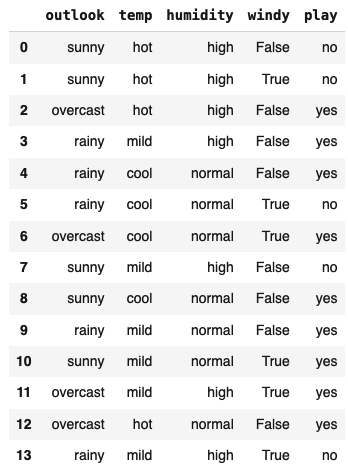

* A decision tree for above data

<img src="https://github.com/awantik/machine-learning-slides/blob/master/dt4.PNG?raw=true" width="600px">

## 2. Decision Tree Algorithms

### ID3 (1986 – Ross Quinlan)
- Uses **Entropy** and **Information Gain**
- Works mainly with **categorical features**
- Designed for **classification only**

---

### C4.5 (Improved ID3)
- Handles **continuous features** using thresholds (e.g., Age > 30)
- Uses **Gain Ratio**
- Supports **tree pruning**
- Used for **classification**

---

### CART (Classification and Regression Trees)
- Developed separately (Breiman et al.)
- Uses:
  - **Gini Impurity** (classification)
- Supports both:
  - **Classification**
  - **Regression**

---

### In Practice (scikit-learn)
- `DecisionTreeClassifier` → uses **CART**
- `DecisionTreeRegressor` → uses **CART**
- Default split criterion → **Gini**

# Step 1: Understanding Entropy and Gini Impurity

Before we begin calculations, let’s **understand why we need these concepts**.

## **Entropy – Measuring Disorder**

**Entropy** measures how **mixed** a dataset is. The more **uncertain** or **diverse** the values in a dataset, the higher the entropy.

### Think of it like a jar of marbles:

- If all marbles are **red**, the jar is **pure** → Entropy = 0.
- If the jar has **half red and half blue** marbles, it is **completely mixed** → Entropy = 1.

Entropy is calculated using the formula:

$ \text{Entropy} = -p_1 \log_2(p_1) - p_2 \log_2(p_2) $

Where:

- $ p_1 $ and $ p_2 $ are the proportions of different classes in the dataset.
- The **higher** the entropy, the more mixed the data.


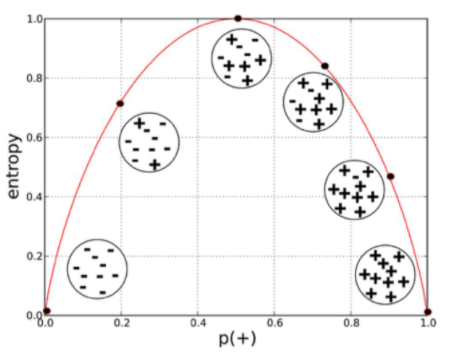

#### **Example Using Marbles**:

Using marble analogy:

- Consider marbles representing outcomes 'R' (for red) and 'B' (for blue).

- For a set with all red marbles (`[R,R,R,R,R,R,R,R,R,R]`) there's no uncertainty, resulting in an entropy of 0.

- For a mixed (`[R,R,R,R,R,B,B,B,B,B]`) set with equal red and blue marbles, the uncertainty is at its peak, leading to a maximum entropy of 1.




## **Gini Impurity – Measuring Impurity**

While entropy measures **disorder**, Gini Impurity measures **mistakes** when making a decision.

### Think of it as making a wrong guess:

- If all marbles are **red**, and you pick one, you're **100% sure** it’s red → **Gini = 0** (no mistakes).
- If half are red and half are blue, you have a **50% chance of making a mistake** → **Gini = 0.5**.

### Gini Impurity formula:

$ \text{Gini} = 1 - (p_1^2 + p_2^2) $

### Where:

- $ p_1 $ and $ p_2 $ are the proportions of different classes.
- **Lower Gini means better splits.**


----
# Step 2: Compute Entropy of the Whole Dataset

We have **14 total samples** with two possible outcomes:

- **9 Yes (Play)**
- **5 No (Play)**

We apply the entropy formula:

$ \text{Entropy} = - \left( \frac{9}{14} \log_2 \frac{9}{14} + \frac{5}{14} \log_2 \frac{5}{14} \right) $


In [ ]:
total_samples = 14

yes_count = 9
no_count = 5

p_yes = yes_count / total_samples
p_no = no_count / total_samples

entropy_total = - (p_yes * np.log2(p_yes) + p_no * np.log2(p_no))

In [ ]:
print("Entropy of the Whole Dataset:", entropy_total)

Entropy of the Whole Dataset: 0.9402859586706311


This means our dataset is fairly mixed, so we need to split it to make it more pure.

----
# Step 3: Splitting by "Outlook"

To make better predictions, we try **splitting the dataset** based on different features.

## Splitting by "Outlook"

We divide the dataset into **three groups**:

1. **Sunny (5 samples)**: [No, No, No, Yes, Yes]
2. **Overcast (4 samples)**: [Yes, Yes, Yes, Yes]
3. **Rainy (5 samples)**: [Yes, Yes, No, Yes, No]

Each of these groups has a different **entropy**, so we compute their entropy separately.


In [ ]:
# Function to calculate entropy
def entropy(counts):
  total = sum(counts)
  probabilities = [c / total for c in counts if c!=0]
  entropy = -sum([p * np.log2(p) for p in probabilities])
  return entropy

In [ ]:
# Entropy for each group
entropy_sunny = entropy([3, 2])
entropy_overcast = entropy([0, 4])
entropy_rainy = entropy([2, 3])

print("Entropy for Sunny:", entropy_sunny)
print("Entropy for Overcast:", entropy_overcast)
print("Entropy for Rainy:", entropy_rainy)

Entropy for Sunny: 0.9709505944546686
Entropy for Overcast: -0.0
Entropy for Rainy: 0.9709505944546686


These results represent the **entropy** for different groups when we split the dataset by the "Outlook" feature.

## What Do These Results Mean?

Entropy measures how **mixed** a dataset is. A lower entropy means the group is **more pure** (i.e., mostly one class: all "Yes" or all "No"). A higher entropy means the group is **more mixed** (i.e., nearly equal "Yes" and "No" values).

- **Entropy for Sunny = 0.97**  
  → The "Sunny" group is **almost equally mixed** between "Yes" and "No," meaning it is not very pure.

- **Entropy for Overcast = 0.0**  
  → The "Overcast" group is **completely pure** (all "Yes"), meaning if "Outlook = Overcast," we can **immediately** predict "Yes" with 100% certainty.

- **Entropy for Rainy = 0.97**  
  → The "Rainy" group is also **almost equally mixed** between "Yes" and "No," meaning it is not very pure.

## Interpretation

- The **Overcast** group is the **best case** because it is **fully predictable**.
- The **Sunny** and **Rainy** groups still have high entropy, so we **need another split** to make them purer.


-----
# Step 4: Compute Information Gain in Detail


## What is Information Gain?

Imagine you have a **messy desk** with books, papers, and pens **all mixed up**.  
You decide to **organize them** into separate piles.

- **Before organizing** → The desk is **very messy** (high entropy).
- **After organizing** → Everything is **neatly sorted** (low entropy).
- **The difference in messiness = Information Gain**.

Similarly, **Information Gain** tells us **how much entropy is reduced** after splitting data.

$ \text{Information Gain} = \text{Entropy Before Split} - \text{Weighted Entropy After Split} $

A **higher Information Gain** means a **better split**, as it makes the data **more organized**.


## Compute Weighted Entropy After Split

Since the dataset is split into three groups, we compute the **weighted average** of their entropy:

We divide the dataset into three groups based on **Outlook**:

- **Sunny (5 samples)**: [No, No, No, Yes, Yes]
- **Overcast (4 samples)**: [Yes, Yes, Yes, Yes] → **Pure Group**
- **Rainy (5 samples)**: [Yes, Yes, No, Yes, No]

We calculate **entropy** for each group:

### **Sunny:**
- **3 No, 2 Yes**  
- $ \text{Entropy} = 0.97 $

### **Overcast:**
- **4 Yes, 0 No**  
- $ \text{Entropy} = 0.0 $ (**Pure Group**)

### **Rainy:**
- **3 Yes, 2 No**  
- $ \text{Entropy} = 0.97 $


We calculate the Weighted Entropy:

$$ \text{Weighted Entropy} = \frac{5}{14} \times 0.97 + \frac{4}{14} \times 0 + \frac{5}{14} \times 0.97 $$


In [ ]:
# Compute weighted entropy after splitting by "Outlook"
weighted_entropy_outlook = (5/14) * entropy_sunny + (4/14) * entropy_overcast + (5/14) * entropy_rainy

print("Weighted Entropy after splitting by Outlook:", weighted_entropy_outlook)

Weighted Entropy after splitting by Outlook: 0.6935361388961918


# Compute Information Gain

Now, we subtract **Weighted Entropy** from **Initial Entropy**:

$ \text{Information Gain} = 0.94 - 0.69 $


In [ ]:
# Compute Information Gain
info_gain_outlook = entropy_total - weighted_entropy_outlook

print("Information Gain for Outlook:", info_gain_outlook)

Information Gain for Outlook: 0.24674981977443933


This means that splitting on "Outlook" reduces uncertainty by 0.25.

# Final Conclusion

- **Entropy Before Split (0.94)** showed the dataset was **mixed**.
- After splitting by **"Outlook"**, **Weighted Entropy (0.69)** was **lower**, meaning the split improved organization.
- **Information Gain (0.25)** confirmed **"Outlook"** was a **good first split**.
- Now we need to **split further** to improve classification.

## Best Next Splits

- For **"Sunny"** → Split by **"Humidity"**.
- For **"Rainy"** → Split by **"Windy"**.


## SKlearn Implementation

**Step 1:** Import the Necessary Libraries and Load the Dataset
In a Google Colab cell, run:

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load the dataset

df = pd.read_csv("/content/loan_default_dataset.csv")
df.head(5)

,Income,Age,CreditScore,LoanAmount,EmploymentYears,Defaulted,InterestRate
0,45795,40,646,245344,16,0,8.515142
1,30860,35,828,157341,16,0,5.787227
2,84886,40,478,424535,16,1,9.345306
3,36265,30,481,190403,10,0,10.000000
4,67194,56,324,360973,31,1,10.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           500 non-null    int64  
 1   Age              500 non-null    int64  
 2   CreditScore      500 non-null    int64  
 3   LoanAmount       500 non-null    int64  
 4   EmploymentYears  500 non-null    int64  
 5   Defaulted        500 non-null    int64  
 6   InterestRate     500 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


**Step 2:** Data Preparation
Separate the features and the target variable. In this case, we'll use Defaulted as the target variable:

In [ ]:
# Features and target separation
X = df.drop(['Defaulted'], axis = 1)
y = df['Defaulted']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((350, 6), (150, 6), (350,), (150,))

**Note on Scaling Data**: Decision trees, in general, don't require feature scaling to perform well. They are not sensitive to the variance in data. However, many other algorithms, especially those that rely on distances (like k-NN) or gradient descent optimization, do benefit from scaling. So, for decision trees, we can skip scaling for now.

Step 3: Train the Decision Tree

In [ ]:
# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier()

Let's perform a grid search for hyperparameter tuning of the decision tree:

**Set Up Grid Search**

### Decision Tree Parameters

### Max Depth

**Definition**: Maximum depth limits how many layers the decision tree can have.

If set to a specific value, like 5, the tree will only split and create branches up to a depth of 5 levels. This prevents the tree from becoming too deep and overfitting the data.

### Min Samples Split

**Definition**: Minimum samples split is the fewest number of data points required to split a node into child nodes.

If set to 2, for example, a node must have at least 2 data points to consider splitting it further. This parameter controls the granularity of the tree; smaller values result in finer, deeper trees.

### Min Samples Leaf

**Definition**: Minimum samples leaf sets the minimum number of data points required in a leaf node.

For instance, if set to 4, a leaf node must contain at least 4 data points. This parameter helps control the size of the leaf nodes and can prevent overfitting by ensuring that each leaf has enough data to make reliable predictions.


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6]
}

Hyperparameters and Criterion

In essence, hyperparameters like `max_depth`, `min_samples_split`, and `min_samples_leaf` control the tree's size and depth, influencing its complexity and tendency to overfit or underfit. Meanwhile, the `criterion` parameter determines the method used to assess split quality.


In [ ]:
# Initialize the classifier
dtc = DecisionTreeClassifier()

In [ ]:
# Initialize grid search
grid_search = GridSearchCV(dtc, param_grid=param_grid, scoring = 'accuracy', return_train_score=True)

In [ ]:
# Fit grid search
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='accuracy')

**Get Best Parameters**
After fitting, you can retrieve the best hyperparameters found by the grid search:

In [ ]:
# Best parameters and their corresponding accuracy
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [ ]:
print(f"Best Score: {grid_search.best_score_:.3f}")

Best Score: 0.983


In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(max_depth=5)

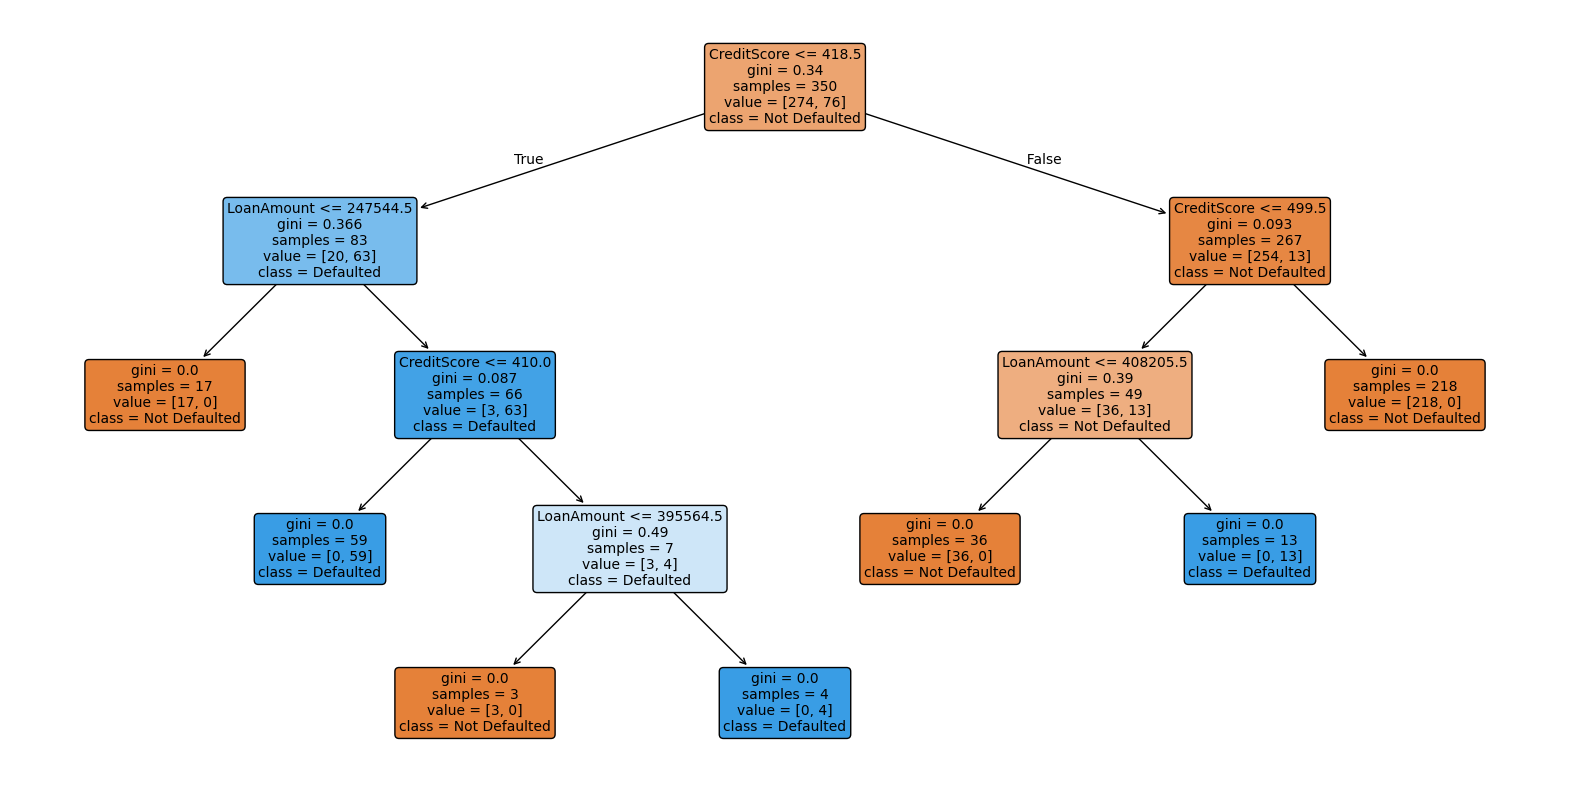

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Set the size of the plot
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(grid_search.best_estimator_, feature_names=X.columns, class_names=['Not Defaulted', 'Defaulted'], filled=True, rounded=True, fontsize=10)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# Predictions on testing data
y_pred = grid_search.predict(X_test)

# Evaluate the classifier
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

Testing Accuracy: 0.9933333333333333


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[109,   1],
       [  0,  40]])

In [ ]:
tn, fp, fn, tp = conf_matrix.ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 109
False Positives: 1
False Negatives: 0
True Positives: 40


### Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       0.98      1.00      0.99        40

    accuracy                           0.99       150
   macro avg       0.99      1.00      0.99       150
weighted avg       0.99      0.99      0.99       150





The classification report is a summary of the performance of a classification model. It provides important metrics that help evaluate how well the model is performing in terms of classifying different categories or classes. The report includes the following metrics:

- **Precision**: Precision is the ratio of true positive predictions to the total number of positive predictions. It measures the accuracy of positive predictions and tells us how many of the predicted positive instances were actually positive.
  -

- **Recall**: Recall is the ratio of true positive predictions to the total number of actual positive instances. It measures the model's ability to correctly identify all positive instances.

- **F1-Score**: The F1-score is the harmonic mean of precision and recall. It provides a balanced measure of a model's performance, considering both false positives and false negatives.

- **Support**: Support is the number of actual instances of each class in the test dataset. It gives context to the other metrics by indicating how many instances belong to each class.

- **Accuracy**: Accuracy is the overall percentage of correctly classified instances. It measures the model's overall performance.

The classification report is a valuable tool for assessing the model's performance, especially in cases with imbalanced datasets or when different classes have varying levels of importance. It helps you understand how well the model is distinguishing between classes and where it may need improvement.


In [ ]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Precision: 0.975609756097561
Recall: 1.0
F1 Score: 0.9876543209876543


### Overfitting Analysis

- **Training Accuracy Much Higher than Testing Accuracy**: This discrepancy is an indicator of overfitting. In such cases, the model has learned the training data too well, capturing noise and outliers, which leads to poorer performance on new, unseen data.

- **High and Equal Training and Testing Accuracies**: When both accuracies are very high and roughly equal (as in this case with a testing accuracy of 0.99), it suggests that the model is performing well and generalizing effectively to new data.


In [ ]:
# Extract the best decision tree estimator from the grid search
best_tree = grid_search.best_estimator_

# Calculate feature importance
feature_importance = best_tree.feature_importances_

In [ ]:
best_tree

DecisionTreeClassifier(max_depth=5)

In [ ]:
feature_importance

array([0.        , 0.        , 0.60363823, 0.39636177, 0.        ,
       0.        ])

In [ ]:
X.columns

Index(['Income', 'Age', 'CreditScore', 'LoanAmount', 'EmploymentYears',
       'InterestRate'],
      dtype='object')

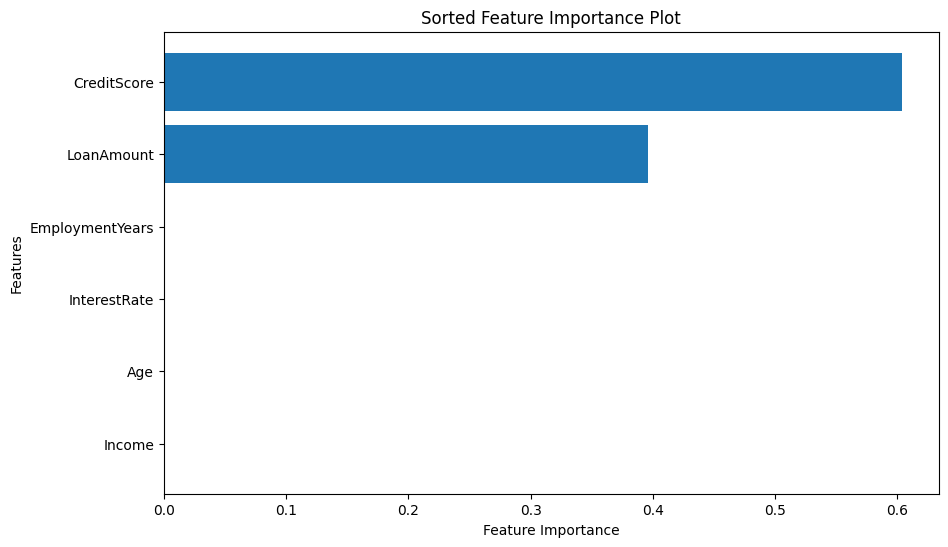

In [ ]:
import numpy as np
# Assuming df is your DataFrame with the original feature order
column_names = X.columns


# Sort the feature importances and column names together
sorted_indices = np.argsort(feature_importance)[::-1]
sorted_feature_importance = feature_importance[sorted_indices]
sorted_column_names = column_names[sorted_indices]


# Create a sorted bar plot with feature names
plt.figure(figsize=(10, 6))

plt.barh(sorted_column_names, sorted_feature_importance)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Sorted Feature Importance Plot')

plt.gca().invert_yaxis()  # Invert y-axis to have the most important features at the top

plt.show()
